In [2]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("powerplant_data.csv")

In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
x = df.drop("PE" , axis =1)
y = df["PE"]

In [9]:
x_train , x_test , y_train , y_test = train_test_split(
    x,y,test_size = 0.2, random_state =42
)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [21]:
import torch
import torch.nn as nn

x_train_tensor = torch.tensor(x_train_scaled , dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values , dtype = torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values , dtype = torch.float32).view(-1,1)
x_test_tensor = torch.tensor(x_test_scaled , dtype = torch.float32)

In [22]:
from torch.utils.data import TensorDataset, DataLoader

# Tensordataset ( input featres , output Features )
train_dataset =TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor , y_test_tensor)

In [25]:
# dataloader creation 
train_loader = DataLoader(train_dataset, batch_size=32, shuffle =True)
test_loader= DataLoader(test_dataset, batch_size=32)

# Deep Learning 

In [41]:
# build our Neural Network model 
class ANN(nn.Module):
    def __init__(self):
        super(ANN , self).__init__()
        self.model = nn.Sequential(
            # 1st hidden layer 
            nn.Linear(x_train.shape[1],6),
            nn.ReLU(),
    
            #2nd hidden layer 
            nn.Linear(6 ,6),
            nn.ReLU(),
    
            #output Layer 
            nn.Linear(6 ,1), 
        )
    def forward(self , x):
        return  self.model(x) # x => x_train data to passing through the froward propagation
    

In [42]:
import torch.optim as Optim
model = ANN()

# loss , Optimizer 
criteria = nn.MSELoss()
optimizer = Optim.Adam(model.parameters())

In [46]:
# Train NN
epochs =100
train_losses =[]
valid_losses =[]
best_val_loss=float("inf") 
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 #total training loss for 1 Epoch

    for xb , yb in train_loader:
        # xb = Features of 1 batch
        # yb = label of 1 batch 
        optimizer.zero_grad() # every time NN new gradient mile 

        outputs = model(xb) # forward propagation .... predicted outputs for this batch 
        loss  = criteria(outputs , yb) # compute the loss
        loss.backward() # backward Propagation .... compute the gradients 
        optimizer.step() # parameter updates

        running_loss = running_loss+loss.item()  # loss is a tensor formate = > python float
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad(): # no gradients compute 
        for xb , yb in test_loader:
            outputs = model(xb)
            loss = criteria(outputs , yb)
            running_val_loss+=loss
    epoch_val_loss = running_val_loss / len(test_loader)
    valid_losses.append(epoch_val_loss)

    print(f"epoch ${epoch+1}/{epochs} ==> training loss = ${epoch_train_loss} & val loss = ${epoch_val_loss}")

    #best model evaluation 
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt") # two way to save file 1) .pt 2) .pth
        
    

epoch $1/100 ==> training loss = $20.70995366970698 & val loss = $19.390893936157227
epoch $2/100 ==> training loss = $20.65974197189013 & val loss = $18.936426162719727
epoch $3/100 ==> training loss = $20.69930674235026 & val loss = $18.71074867248535
epoch $4/100 ==> training loss = $20.628831477959952 & val loss = $18.77618980407715
epoch $5/100 ==> training loss = $20.669154528776804 & val loss = $19.43543243408203
epoch $6/100 ==> training loss = $20.649815320968628 & val loss = $18.68182945251465
epoch $7/100 ==> training loss = $20.620731059710184 & val loss = $18.860685348510742
epoch $8/100 ==> training loss = $20.59946056207021 & val loss = $18.969486236572266
epoch $9/100 ==> training loss = $20.504821214079858 & val loss = $18.890625
epoch $10/100 ==> training loss = $20.514208487669627 & val loss = $19.63802146911621
epoch $11/100 ==> training loss = $20.853039642175037 & val loss = $18.740636825561523
epoch $12/100 ==> training loss = $20.7750541806221 & val loss = $19.1

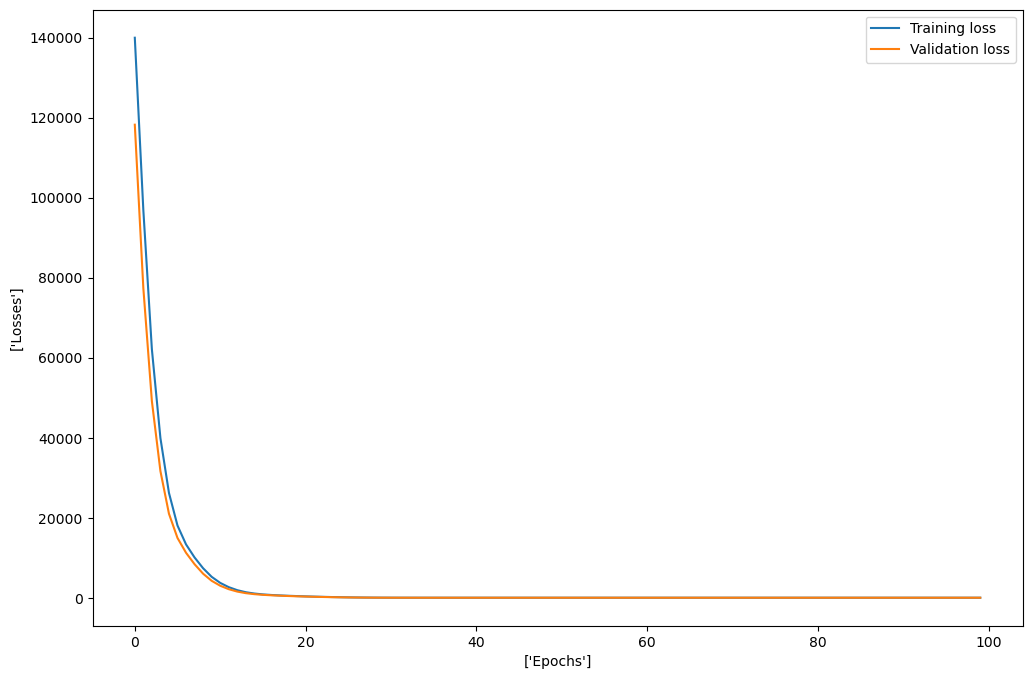

In [40]:
import matplotlib.pyplot as plt

loss_df =pd.DataFrame({
    "Training loss" : train_losses,
    "Validation loss" : valid_losses
        }
                     )
plt.figure(figsize =(12 , 8))
plt.plot(loss_df["Training loss"] , label  = "Training loss")
plt.plot(loss_df["Validation loss"] , label  = "Validation loss")

plt.xlabel(["Epochs"])
plt.ylabel(["Losses"])

plt.legend()

In [45]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [48]:
# evaluation 
model.eval()
with torch.no_grad():
    train_preds = model(x_train_tensor)
    test_preds = model(x_test_tensor)

    train_mse_loss = criteria(train_preds, y_train_tensor)
    test_mse_loss = criteria(test_preds , y_test_tensor)

print("training MSE :" ,  train_mse_loss.item())
print("test MSE :" ,  test_mse_loss.item())


training MSE : 20.319076538085938
test MSE : 18.777429580688477


In [49]:
from sklearn.metrics  import r2_score
print("r2 socre : ", r2_score(y_test , test_preds)) 

r2 socre :  0.9343777285123931


In [51]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns =["predicted values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df , actual_df] , axis =1)

,predicted values,Actual Values
0,435.741608,433.27
1,437.039154,438.16
2,461.803131,458.42
3,476.751740,480.82
4,435.619781,441.41
...,...,...
1909,451.786255,456.70
1910,431.878632,438.04
1911,468.293121,467.80
1912,431.232147,437.14
